## Baseline BART Dialogue Model

This gives us the baseline BLEU/ROUGE/METEOR scores that our emotion-conditioned model will be compared against.

Dataset is available on: https://www.kaggle.com/datasets/thedevastator/dailydialog-unlock-the-conversation-potential-in/data

## Section 1: Install Dependencies

In [2]:
# Install required libraries
# rouge-score: for ROUGE-L evaluation
# nltk: for BLEU and METEOR
# transformers + datasets: HuggingFace ecosystem
!pip install -q transformers datasets rouge-score nltk sentencepiece accelerate

In [3]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)  # needed for METEOR

import os
import ast
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BartTokenizer, BartForConditionalGeneration, get_linear_schedule_with_warmup
from torch.optim import AdamW
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [4]:

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## Section 2: Mount Google Drive & Load Data

In [5]:

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/NeuralNetworks/Project/Dataset/train.csv'
SAVE_DIR = '/content/drive/MyDrive/NeuralNetworks/Project/checkpoints/baseline'
os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive



## Section 3: Parse DailyDialog CSV

The CSV has three columns: `dialog`, `act`, `emotion`.
- `dialog` is a Python list (as a string) of utterance strings.
- `emotion` is a bracketed array of integers: 0=neutral, 1=happiness, 2=sadness, 3=anger, 4=surprise, 5=disgust, 6=fear.

We convert each dialogue into (context, response) pairs:
- context = all turns up to turn N joined with a separator
- response = turn N+1
- emotion = emotion label of the response turn

In [6]:
EMOTION_MAP = {
    0: "neutral",
    1: "anger",
    2: "disgust",
    3: "fear",
    4: "happiness",
    5: "sadness",
    6: "surprise"
}
import re
def parse_array_string(s):
    """Parse bracketed integer arrays like '[0 0 1 4]' into a Python list."""
    s = s.strip().strip('[]')
    return [int(x) for x in s.split()]

def parse_dialog_string(s):
    """
    Extract individual utterances by splitting on the boundary between
    adjacent quoted strings in the serialized list.
    Pattern: end of one quote, whitespace/newline, start of next quote.
    """
    s = s.strip()
    if s.startswith('['):
        s = s[1:]
    if s.endswith(']'):
        s = s[:-1]
    parts = re.split(r"""['"]\s*\n\s*['"']""", s)

    turns = []
    for part in parts:
        cleaned = part.strip().strip("'\"").strip()
        if cleaned:
            turns.append(cleaned)

    return turns if len(turns) >= 2 else None


def build_pairs(df, context_window=3):
    """
    Convert raw DataFrame rows into (context, response, emotion_label) triples.
    context_window: how many prior turns to include as context
    """
    pairs = []
    for _, row in df.iterrows():
        turns = parse_dialog_string(row['dialog'])
        emotions = parse_array_string(row['emotion'])
        if turns is None or len(turns) < 2:
            continue
        if len(turns) != len(emotions):
            continue
        for i in range(1, len(turns)):
            ctx_turns = turns[max(0, i - context_window):i]
            context = ' [SEP] '.join(ctx_turns)
            response = turns[i]
            emotion = emotions[i]
            pairs.append({
                'context': context,
                'response': response,
                'emotion': emotion,
                'emotion_label': EMOTION_MAP[emotion]
            })
    return pairs

# Load CSV
df_raw = pd.read_csv(DATA_PATH)
print(f'Total dialogues: {len(df_raw)}')
print(df_raw.head(2))

Total dialogues: 11118
                                              dialog                    act  \
0  ['Say , Jim , how about going for a few beers ...  [3 4 2 2 2 3 4 1 3 4]   
1  ['Can you do push-ups ? '\n " Of course I can ...          [2 1 2 2 1 1]   

                 emotion  
0  [0 0 0 0 0 0 4 4 4 4]  
1          [0 0 6 0 0 0]  


In [7]:
import ast

def parse_dialog_string(s):
    """Parse the dialog column (a Python list literal) into a list of utterance strings."""
    try:
        s_cleaned = s.replace("'\n '", "', '")
        turns = ast.literal_eval(s_cleaned)
        return [t.strip() for t in turns]
    except (ValueError, SyntaxError) as e:
        return None
SUBSET = None

# Build (context, response, emotion) triples
all_pairs = build_pairs(df_raw, context_window=3)
print(f'Total training pairs: {len(all_pairs)}')

Total training pairs: 10480


In [8]:
# Train / Val / Test split  (80 / 10 / 10)
random.shuffle(all_pairs)
n = len(all_pairs)
train_pairs = all_pairs[:int(0.8 * n)]
val_pairs   = all_pairs[int(0.8 * n):int(0.9 * n)]
test_pairs  = all_pairs[int(0.9 * n):]

print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')

# Emotion distribution in training set
from collections import Counter
emo_counts = Counter(p['emotion_label'] for p in train_pairs)
print('\nEmotion distribution (train):')
for emo, cnt in sorted(emo_counts.items()):
    print(f'  {emo:12s}: {cnt:5d} ({cnt/len(train_pairs)*100:.1f}%)')

Train: 8384 | Val: 1048 | Test: 1048

Emotion distribution (train):
  anger       :   101 (1.2%)
  disgust     :    33 (0.4%)
  fear        :    10 (0.1%)
  happiness   :   934 (11.1%)
  neutral     :  7059 (84.2%)
  sadness     :    86 (1.0%)
  surprise    :   161 (1.9%)



## Section 4: Tokenization & Dataset Class

In [9]:
# ---- HYPERPARAMETERS ---- =
MODEL_NAME      = 'facebook/bart-base'
MAX_INPUT_LEN   = 128    # max tokens for context
MAX_TARGET_LEN  = 64     # max tokens for response
BATCH_SIZE      = 8
GRAD_ACCUM      = 4
EPOCHS          = 5
LR              = 3e-5
WARMUP_STEPS    = 100

tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
print(f'Vocab size: {tokenizer.vocab_size}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 50265


In [10]:
class DialogDataset(Dataset):
    """
    PyTorch Dataset for (context, response) pairs.
    Tokenizes context as encoder input and response as decoder labels.
    Padding tokens in labels are -100 so they are ignored by the loss.
    """
    def __init__(self, pairs, tokenizer, max_input_len, max_target_len):
        self.pairs = pairs
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        # Tokenize encoder input (context)
        enc = self.tokenizer(
            pair['context'],
            max_length=self.max_input_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Tokenize decoder target (response)
        dec = self.tokenizer(
            pair['response'],
            max_length=self.max_target_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        labels = dec['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         labels,
            'emotion':        pair['emotion']
        }

# Build datasets and loaders
train_dataset = DialogDataset(train_pairs, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
val_dataset   = DialogDataset(val_pairs,   tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
test_dataset  = DialogDataset(test_pairs,  tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')

Train batches: 1048 | Val batches: 131 | Test batches: 131



## Section 5: Load Model & Set Up Optimizer

In [11]:
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params/1e6:.1f}M')
print(f'Trainable parameters: {trainable_params/1e6:.1f}M')

# Optimizer
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

# Linear warmup + decay scheduler
total_steps = (len(train_loader) // GRAD_ACCUM) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)
print(f'Total optimizer steps: {total_steps}')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Total parameters:     139.4M
Trainable parameters: 139.4M
Total optimizer steps: 1310



## Section 6: Training Loop

In [12]:
def train_one_epoch(model, loader, optimizer, scheduler, device, grad_accum):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc='Training')):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss / grad_accum
        loss.backward()
        total_loss += outputs.loss.item()

        if (step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

    return total_loss / len(loader)


def evaluate_loss(model, loader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            total_loss += outputs.loss.item()
    return total_loss / len(loader)

In [13]:
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    print(f'\n===== EPOCH {epoch}/{EPOCHS} =====')
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE, GRAD_ACCUM)
    val_loss   = evaluate_loss(model, val_loader, DEVICE)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    # Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f'  --> New best model saved to {SAVE_DIR}')

print(f'\nBest Val Loss: {best_val_loss:.4f}')


===== EPOCH 1/5 =====


Training:   0%|          | 0/1048 [00:00<?, ?it/s]

Validation:   0%|          | 0/131 [00:00<?, ?it/s]

Train Loss: 3.1364 | Val Loss: 2.5655


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training:   0%|          | 0/1048 [00:00<?, ?it/s]

Validation:   0%|          | 0/131 [00:00<?, ?it/s]

Train Loss: 2.3083 | Val Loss: 2.3939


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  --> New best model saved to /content/drive/MyDrive/NeuralNetworks/Project/checkpoints/baseline

Best Val Loss: 2.3939


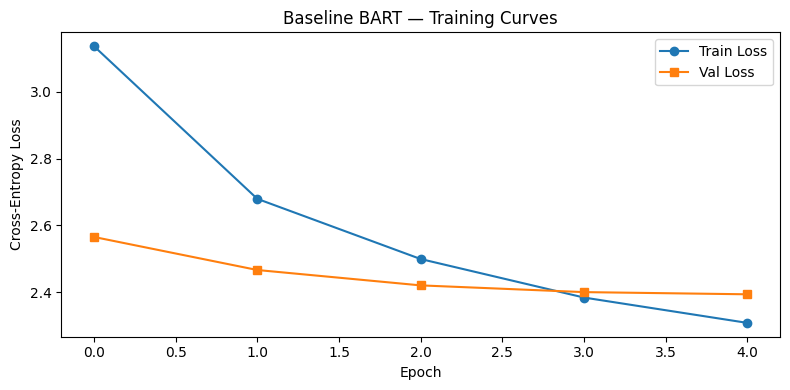

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'],   label='Val Loss',   marker='s')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Baseline BART — Training Curves')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves_baseline.png'), dpi=150)
plt.show()


## Section 7: Generate Responses on Test Set

In [15]:
# Load best checkpoint for inference
model = BartForConditionalGeneration.from_pretrained(SAVE_DIR).to(DEVICE)
model.eval()

def generate_responses(model, tokenizer, pairs, device, batch_size=16,
                        max_input_len=128, max_gen_len=64,
                        num_beams=4, no_repeat_ngram_size=3):
    """
    Generate responses for a list of (context, response) pairs.
    Returns list of generated strings.
    """
    all_generated = []
    for i in tqdm(range(0, len(pairs), batch_size), desc='Generating'):
        batch_pairs = pairs[i:i + batch_size]
        contexts = [p['context'] for p in batch_pairs]

        enc = tokenizer(
            contexts,
            max_length=max_input_len,
            padding=True,
            truncation=True,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            output_ids = model.generate(
                input_ids=enc['input_ids'],
                attention_mask=enc['attention_mask'],
                max_new_tokens=max_gen_len,
                num_beams=num_beams,
                no_repeat_ngram_size=no_repeat_ngram_size,
                early_stopping=True
            )

        decoded = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
        all_generated.extend(decoded)

    return all_generated

generated = generate_responses(model, tokenizer, test_pairs, DEVICE)
references = [p['response'] for p in test_pairs]

print('\n--- Sample outputs ---')
for i in range(3):
    print(f'\n[{i+1}] Context  : {test_pairs[i]["context"]}')
    print(f'    Reference: {references[i]}')
    print(f'    Generated: {generated[i]}')
    print(f'    Emotion  : {test_pairs[i]["emotion_label"]}')

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Generating:   0%|          | 0/66 [00:00<?, ?it/s]


--- Sample outputs ---

[1] Context  : Hi , Lilly , it ’ s so nice to see you again . [SEP] Hum , me too . This winter holiday was especially long . What have you done ? [SEP] Nothing special . I had a get-together with some schoolmates at the high school , visited the Internet and read a couple of books which I had been longing for . How about yours ?
    Reference: You know , I like traveling . I made good use of this long vacation and enjoyed myself .
    Generated: Well , I ’ m really looking forward to seeing you again .
    Emotion  : happiness

[2] Context  : Oh don ’ t worry , sweetie , I didn ’ t know when you were going to propose . It was still a nice surprise ! As I was saying , I ’ Ve got it all planned out . There ’ s almost nothing left to do ! I wrote up our guest list and we will have roughly four hundred guests attending . [SEP] Four hundred ? [SEP] No need to sweat it . My parents agreed to pay for most of the wedding , which is going to be low-budget anyway . So ro


## Section 8: Evaluation — BLEU-4, ROUGE-L, METEOR

In [16]:
def compute_bleu4(references, hypotheses):
    """
    Corpus-level BLEU-4.
    references: list of reference strings
    hypotheses: list of generated strings
    """
    ref_tokens  = [[nltk.word_tokenize(r.lower())] for r in references]
    hyp_tokens  = [nltk.word_tokenize(h.lower()) for h in hypotheses]
    smoothie = SmoothingFunction().method1
    score = corpus_bleu(ref_tokens, hyp_tokens, weights=(0.25, 0.25, 0.25, 0.25),
                        smoothing_function=smoothie)
    return score * 100


def compute_rougeL(references, hypotheses):
    """
    Average ROUGE-L F1 across all pairs.
    """
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    scores = [scorer.score(ref, hyp)['rougeL'].fmeasure
              for ref, hyp in zip(references, hypotheses)]
    return np.mean(scores) * 100


def compute_meteor(references, hypotheses):
    """
    Average sentence-level METEOR score.
    """
    scores = [
        meteor_score(
            [nltk.word_tokenize(ref.lower())],
            nltk.word_tokenize(hyp.lower())
        )
        for ref, hyp in zip(references, hypotheses)
    ]
    return np.mean(scores) * 100


def compute_distinct(hypotheses, n=2):
    """
    Distinct-n: ratio of unique n-grams to total n-grams across all generated responses.
    Measures lexical diversity — higher is better.
    """
    all_ngrams = []
    for h in hypotheses:
        tokens = nltk.word_tokenize(h.lower())
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
        all_ngrams.extend(ngrams)
    if len(all_ngrams) == 0:
        return 0.0
    return len(set(all_ngrams)) / len(all_ngrams) * 100

bleu4   = compute_bleu4(references, generated)
rougeL  = compute_rougeL(references, generated)
meteor  = compute_meteor(references, generated)
dist1   = compute_distinct(generated, n=1)
dist2   = compute_distinct(generated, n=2)

results = {
    'Model':      'Baseline (no emotion)',
    'BLEU-4':     round(bleu4,  2),
    'ROUGE-L':    round(rougeL, 2),
    'METEOR':     round(meteor, 2),
    'Distinct-1': round(dist1,  2),
    'Distinct-2': round(dist2,  2),
}

print('\n====== BASELINE RESULTS ======')
for k, v in results.items():
    print(f'  {k:20s}: {v}')

import json
results_path = os.path.join(SAVE_DIR, 'baseline_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)


====== BASELINE RESULTS ======
  Model               : Baseline (no emotion)
  BLEU-4              : 3.06
  ROUGE-L             : 14.27
  METEOR              : 14.24
  Distinct-1          : 10.62
  Distinct-2          : 36.1


In [17]:
output_df = pd.DataFrame({
    'context':    [p['context']       for p in test_pairs],
    'reference':  references,
    'generated':  generated,
    'emotion':    [p['emotion_label'] for p in test_pairs]
})
output_csv = os.path.join(SAVE_DIR, 'baseline_test_outputs.csv')
output_df.to_csv(output_csv, index=False)
output_df.head(10)

,context,reference,generated,emotion
0,"Hi , Lilly , it ’ s so nice to see you again ....","You know , I like traveling . I made good use ...","Well , I ’ m really looking forward to seeing ...",happiness
1,"Oh don ’ t worry , sweetie , I didn ’ t know w...",Ah ...,That ’ s a good idea . I ’ m sure we ’ ll have...,neutral
2,"Calvin , how much money did you spend last wee...",Why don ’ t you help me save money ? You are a...,I think I spent $ 50 .,anger
3,"Let ’ s meet before next week ’ s meeting , Ja...","Well , let ’ s plan to get together next Monda...",That ’ s fine . I ’ ll see you next week .,neutral
4,I am thinking about resigning from my current ...,Have you thought about it seriously ?,I am thinking about resigning from my current ...,neutral
5,What is your most preferred training method ? ...,"Well , that is also very efficient , right ?",Do you prefer active training or passive train...,neutral
6,What ’ s the first thing you do when you go to...,"I look at myself in the mirror . Sometimes , i...",I go to the bathroom in the morning .,neutral
7,"No , some jobs are exempt from paying into une...",How will I know how much I can collect on unem...,How can I find out if I have been paying into ...,neutral
8,"Alice , your father is amazing . He ’ s 90 yea...",I know . He doesn ’ t like to ask anyone for h...,That ’ s a pity . He would have been so happy ...,neutral
9,Who was the best teacher that you ever had ?,"That would have to be Miss Baymler , my fourth...",He was the best teacher I ever had .,neutral
